In [11]:
# K-Means Clustering - Segmentasi & Prioritas Penjualan Inventory Berdasarkan Perputaran Stok dan Lama Penyimpanan Barang
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [12]:
# 1. LOAD DATA
print("1. LOAD DATA")

sheet_id = "1__cs0dIpOy9rUekdLE7Dm66fIisDAL6DY1POfneEL1w"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

df = pd.read_csv(url)

# bersihkan nama kolom
df.columns = df.columns.str.strip()

print(f"Data berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")
print("\nDaftar Kolom:")
print(df.columns.tolist())

1. LOAD DATA
Data berhasil dimuat: 1309 baris, 12 kolom

Daftar Kolom:
['Entitas', 'Resource', 'Product Name', 'Category', 'BU', 'Site', 'Warehouse', 'Inventory: Quantity', 'Inventory: Amount', 'Average unit cost', 'Aging', 'PIC']


In [13]:
# 2. PREPROCESSING
print("2. PREPROCESSING")

# 2a. konveri Aging dari teks ke angka buat nyari midpoint
aging_map = {
    '361-540 (Days)': 450,
    '541-720 (Days)': 630,
    '720+ Prior date': 720
}
df['Aging_Numeric'] = df['Aging'].map(aging_map)
print(f"Konversi Aging ke numerik:")
for k, v in aging_map.items():
    count = (df['Aging'] == k).sum()
    print(f"  '{k}' → {v} hari  ({count} barang)")

# 2b. pilih fitur untuk K-Means
features = ['Inventory: Quantity', 'Inventory: Amount', 'Average unit cost', 'Aging_Numeric']

# PROSES PEMBERSIHAN STRING KE NUMERIK
for col in features:
    # jika kolom bertipe objek/string, bersihkan koma dan ubah ke numerik
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '', regex=False)

    # paksa konversi ke numerik, jika ada teks yang gagal konversi akan diubah jadi NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

X = df[features].copy()

# 2c. cek missing values (termasuk jika ada yang gagal konversi akibat 'coerce')
missing_count = X.isnull().sum().sum()
print(f"\nMissing values di fitur: {missing_count} (harus 0)")

# jika ada missing values baru setelah konversi, isi dengan 0 atau drop
if missing_count > 0:
    X = X.fillna(0)
    print("Catatan: Ditemukan nilai non-numerik yang tidak valid, otomatis diisi dengan 0.")

# 2d. normalisasi dengan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2. PREPROCESSING
Konversi Aging ke numerik:
  '361-540 (Days)' → 450 hari  (515 barang)
  '541-720 (Days)' → 630 hari  (224 barang)
  '720+ Prior date' → 720 hari  (570 barang)

Missing values di fitur: 2 (harus 0)
Catatan: Ditemukan nilai non-numerik yang tidak valid, otomatis diisi dengan 0.


3. MENENTUKAN JUMLAH CLUSTER OPTIMAL
   K |      Inertia | Silhouette Score
----------------------------------------
   2 |       3447.1 |           0.9187
   3 |       2214.0 |           0.6981
   4 |       1231.6 |           0.7234
   5 |        818.7 |           0.7529
   6 |        671.8 |           0.7722
   7 |        514.8 |           0.7887
   8 |        410.8 |           0.7896


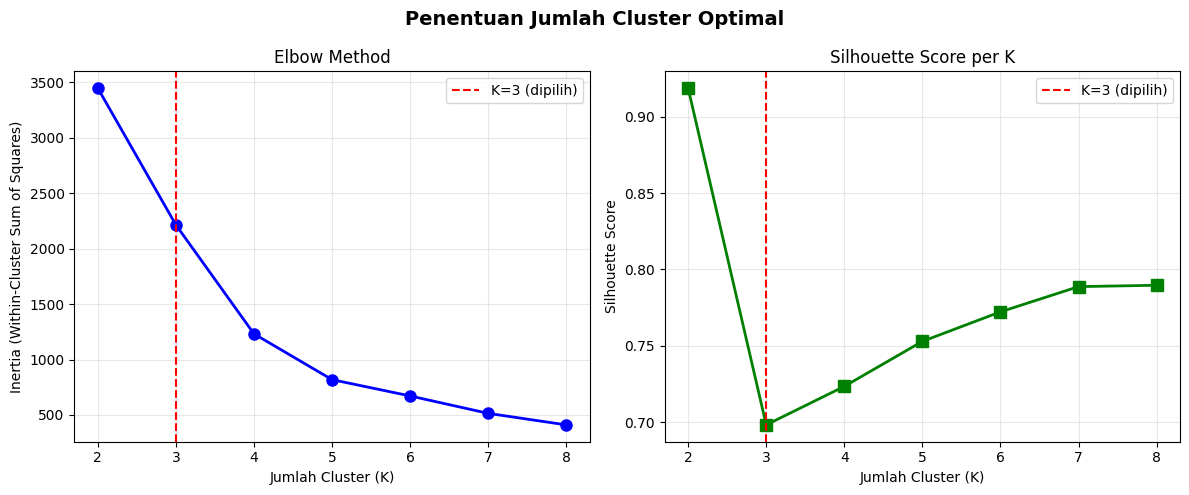

In [14]:
# 3. MENENTUKAN JUMLAH CLUSTER OPTIMAL (ELBOW dan SILHOUETTE)
print("3. MENENTUKAN JUMLAH CLUSTER OPTIMAL")

K_range = range(2, 9)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

print(f"{'K':>4} | {'Inertia':>12} | {'Silhouette Score':>16}")
print("-" * 40)
for k, i, s in zip(K_range, inertias, silhouettes):
    print(f"{k:>4} | {i:>12.1f} | {s:>16.4f}")

# Plot Elbow & Silhouette
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Penentuan Jumlah Cluster Optimal', fontsize=14, fontweight='bold')

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', label='K=3 (dipilih)')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), silhouettes, 'gs-', linewidth=2, markersize=8)
axes[1].axvline(x=3, color='red', linestyle='--', label='K=3 (dipilih)')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per K')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# 4. TRAINING K-MEANS (K=3)
print("4. TRAINING K-MEANS (K=3)")

K_OPTIMAL = 3
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score (K=3): {sil_score:.4f}")
print(f"Inertia (K=3): {kmeans.inertia_:.2f}")

4. TRAINING K-MEANS (K=3)
Silhouette Score (K=3): 0.6981
Inertia (K=3): 2214.05


In [16]:
# 5. INTERPRETASI CLUSTER & LABELING PRIORITAS
print("5. INTERPRETASI CLUSTER")

cluster_profile = df.groupby('Cluster')[features].mean()
cluster_profile['Jumlah Barang'] = df.groupby('Cluster').size()
print(cluster_profile.round(2).to_string())

# tektukan label berdasarkan rata-rata Aging_Numeric per cluster
aging_means = df.groupby('Cluster')['Aging_Numeric'].mean()
amount_means = df.groupby('Cluster')['Inventory: Amount'].mean()

# buat skor prioritas: gabungan aging (bobot 60%) + amount (bobot 40%)
aging_normalized = (aging_means - aging_means.min()) / (aging_means.max() - aging_means.min() + 1e-9)
amount_normalized = (amount_means - amount_means.min()) / (amount_means.max() - amount_means.min() + 1e-9)
priority_score = 0.6 * aging_normalized + 0.4 * amount_normalized

# rank: skor tertinggi = prioritas pertama
priority_rank = priority_score.rank(ascending=False).astype(int)

label_map_name = {
    priority_rank.idxmin(): "JUAL SEGERA",
    priority_rank.sort_values().index[1]: "PERLU DIPERHATIKAN",
    priority_rank.idxmax(): "AMAN"
}

priority_label_map = {
    priority_rank.idxmin(): 1,
    priority_rank.sort_values().index[1]: 2,
    priority_rank.idxmax(): 3
}

df['Label'] = df['Cluster'].map(label_map_name)
df['Prioritas'] = df['Cluster'].map(priority_label_map)

print("\nLabel per Cluster:")
for c in sorted(df['Cluster'].unique()):
    label = label_map_name[c]
    count = (df['Cluster'] == c).sum()
    avg_aging = df[df['Cluster'] == c]['Aging_Numeric'].mean()
    avg_amount = df[df['Cluster'] == c]['Inventory: Amount'].mean()
    print(f"  Cluster {c} → {label} | {count} barang | Aging rata2: {avg_aging:.0f} hari | Amount rata2: Rp {avg_amount:,.0f}")

5. INTERPRETASI CLUSTER
         Inventory: Quantity  Inventory: Amount  Average unit cost  Aging_Numeric  Jumlah Barang
Cluster                                                                                         
0                      30.68       1.550444e+07       1.104279e+07         450.00            510
1                     148.26       9.511677e+06       5.058249e+06         694.61            794
2                       1.00       9.549790e+08       9.549790e+08         450.00              5

Label per Cluster:
  Cluster 0 → AMAN | 510 barang | Aging rata2: 450 hari | Amount rata2: Rp 15,504,444
  Cluster 1 → JUAL SEGERA | 794 barang | Aging rata2: 695 hari | Amount rata2: Rp 9,511,677
  Cluster 2 → PERLU DIPERHATIKAN | 5 barang | Aging rata2: 450 hari | Amount rata2: Rp 954,978,962


6. MEMBUAT VISUALISASI


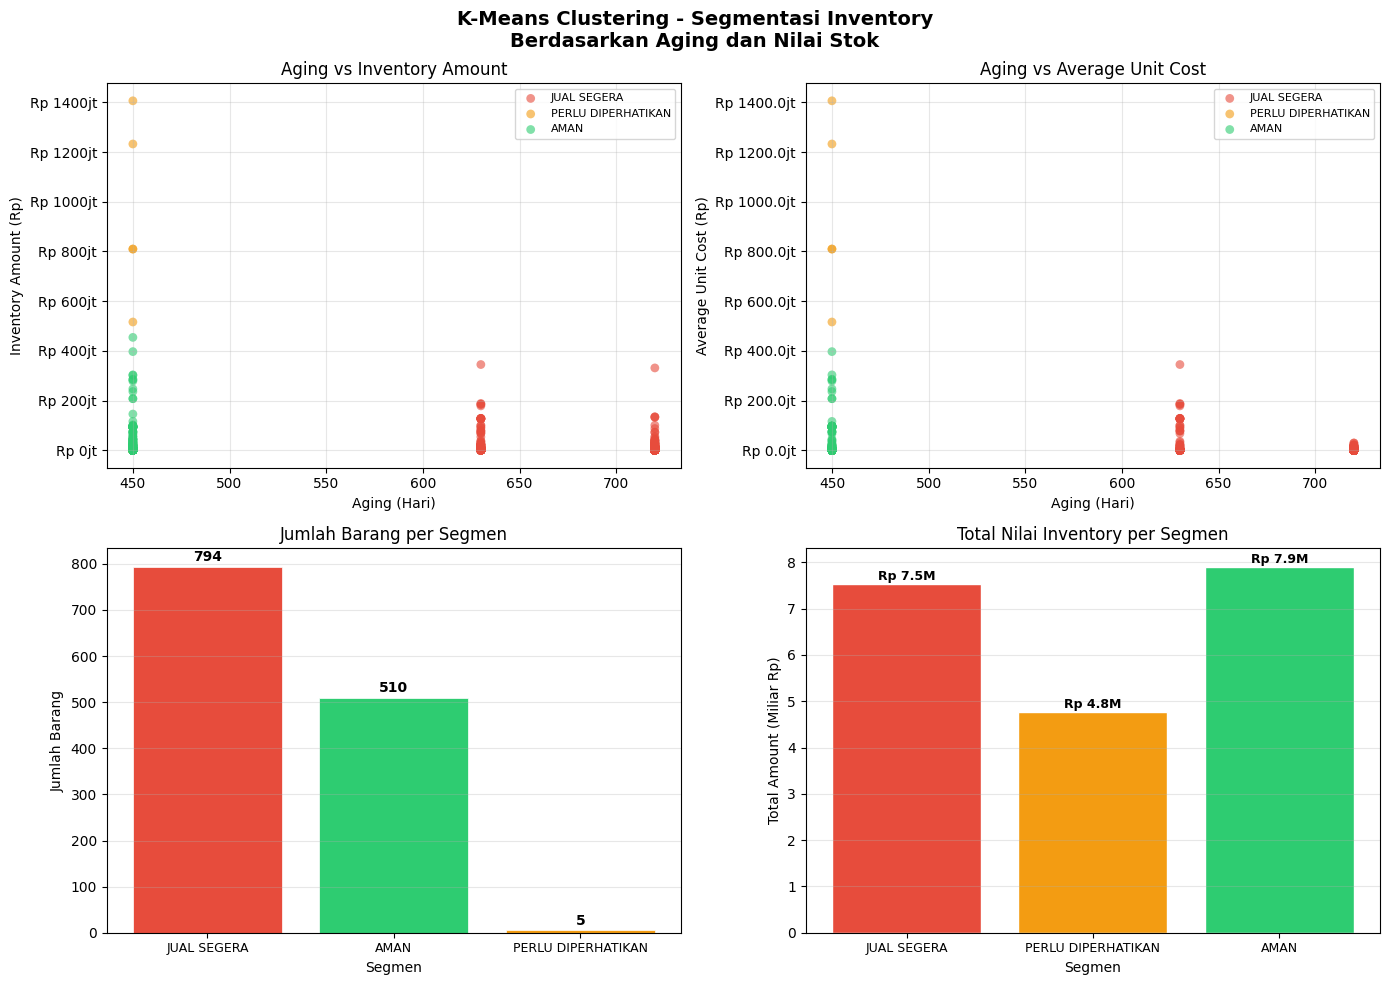

In [17]:
# 6. VISUALISASI
print("6. MEMBUAT VISUALISASI")

colors = {'JUAL SEGERA': '#e74c3c', 'PERLU DIPERHATIKAN': '#f39c12', 'AMAN': '#2ecc71'}
color_list = [colors[df[df['Cluster'] == c]['Label'].iloc[0]] for c in sorted(df['Cluster'].unique())]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('K-Means Clustering - Segmentasi Inventory\nBerdasarkan Aging dan Nilai Stok',
             fontsize=14, fontweight='bold')

# plot 1: Scatter Aging vs Amount
ax1 = axes[0, 0]
for label, color in colors.items():
    subset = df[df['Label'] == label]
    ax1.scatter(subset['Aging_Numeric'], subset['Inventory: Amount'],
                c=color, label=label, alpha=0.6, s=40, edgecolors='none')
ax1.set_xlabel('Aging (Hari)')
ax1.set_ylabel('Inventory Amount (Rp)')
ax1.set_title('Aging vs Inventory Amount')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'Rp {x/1e6:.0f}jt'))
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# plot 2: Scatter Aging vs Avg Unit Cost
ax2 = axes[0, 1]
for label, color in colors.items():
    subset = df[df['Label'] == label]
    ax2.scatter(subset['Aging_Numeric'], subset['Average unit cost'],
                c=color, label=label, alpha=0.6, s=40, edgecolors='none')
ax2.set_xlabel('Aging (Hari)')
ax2.set_ylabel('Average Unit Cost (Rp)')
ax2.set_title('Aging vs Average Unit Cost')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt'))
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# plot 3: Bar chart jumlah barang per cluster
ax3 = axes[1, 0]
label_counts = df['Label'].value_counts()
bar_colors = [colors[l] for l in label_counts.index]
bars = ax3.bar(label_counts.index, label_counts.values, color=bar_colors, edgecolor='white', linewidth=0.5)
ax3.set_xlabel('Segmen')
ax3.set_ylabel('Jumlah Barang')
ax3.set_title('Jumlah Barang per Segmen')
ax3.set_xticklabels(label_counts.index, fontsize=9)
for bar, val in zip(bars, label_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# plot 4: Bar chart total amount per cluster
ax4 = axes[1, 1]
amount_per_label = df.groupby('Label')['Inventory: Amount'].sum() / 1e9
amount_per_label = amount_per_label.reindex(['JUAL SEGERA', 'PERLU DIPERHATIKAN', 'AMAN'])
bar_colors2 = [colors[l] for l in amount_per_label.index]
bars2 = ax4.bar(amount_per_label.index, amount_per_label.values, color=bar_colors2, edgecolor='white')
ax4.set_xlabel('Segmen')
ax4.set_ylabel('Total Amount (Miliar Rp)')
ax4.set_title('Total Nilai Inventory per Segmen')
ax4.set_xticklabels(amount_per_label.index, fontsize=9)
for bar, val in zip(bars2, amount_per_label.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'Rp {val:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [18]:
# 7. OUTPUT - TABEL PRIORITAS PENJUALAN
print("7. OUTPUT HASIL CLUSTERING")

output_cols = ['Entitas', 'Resource', 'Product Name', 'Category', 'BU',
               'Site', 'Warehouse', 'Inventory: Quantity', 'Inventory: Amount',
               'Average unit cost', 'Aging', 'Aging_Numeric', 'PIC', 'Cluster', 'Label', 'Prioritas']

output_cols = [col for col in output_cols if col in df.columns]

df_output = df[output_cols].sort_values(['Prioritas', 'Aging_Numeric', 'Inventory: Amount'],
                                        ascending=[True, False, False])

# simpan ke Excel dengan formatting warna
with pd.ExcelWriter('hasil_clustering_inventory.xlsx', engine='openpyxl') as writer:
    # sheet 1: Semua data
    df_output.to_excel(writer, sheet_name='Hasil Clustering', index=False)

    # sheet 2: Ringkasan per cluster
    summary = df.groupby('Label').agg(
        Jumlah_Barang=('Product Name', 'count'),
        Total_Quantity=('Inventory: Quantity', 'sum'),
        Total_Amount=('Inventory: Amount', 'sum'),
        Avg_Unit_Cost=('Average unit cost', 'mean'),
        Avg_Aging_Hari=('Aging_Numeric', 'mean'),
    ).round(2)
    summary.to_excel(writer, sheet_name='Ringkasan', index=True)

    # sheey 3: Prioritas 1 saja (jual segera)
    df_p1 = df_output[df_output['Prioritas'] == 1]
    df_p1.to_excel(writer, sheet_name='Prioritas 1 - Jual Segera', index=False)

print("File Excel disimpan: hasil_clustering_inventory.xlsx")

# print ringkasan akhir
print("\n" + "=" * 60)
print("RINGKASAN HASIL CLUSTERING")
print("=" * 60)
summary_print = df.groupby(['Label', 'Prioritas']).agg(
    Jumlah_Barang=('Product Name', 'count'),
    Total_Amount=('Inventory: Amount', 'sum'),
    Avg_Aging=('Aging_Numeric', 'mean')
).sort_values('Prioritas')

print(summary_print.to_string())

7. OUTPUT HASIL CLUSTERING
File Excel disimpan: hasil_clustering_inventory.xlsx

RINGKASAN HASIL CLUSTERING
                              Jumlah_Barang  Total_Amount   Avg_Aging
Label              Prioritas                                         
JUAL SEGERA        1                    794  7.542760e+09  694.609572
PERLU DIPERHATIKAN 2                      5  4.774895e+09  450.000000
AMAN               3                    510  7.907266e+09  450.000000


In [19]:
# 8. TAMPILKAN DAFTAR BARANG PER SEGMEN
kolom_tampil = ['Product Name', 'Category', 'BU', 'Warehouse',
                'Inventory: Quantity', 'Inventory: Amount', 'Aging', 'PIC']

# JUAL SEGERA
print("JUAL SEGERA")
jual_segera = df[df['Label'] == 'JUAL SEGERA'][kolom_tampil].sort_values('Inventory: Amount', ascending=False)
display(jual_segera.reset_index(drop=True))

# PERLU DIPERHATIKAN
print("\n" + "=" * 60)
print("PERLU DIPERHATIKAN")
print("=" * 60)
perlu_perhatian = df[df['Label'] == 'PERLU DIPERHATIKAN'][kolom_tampil].sort_values('Inventory: Amount', ascending=False)
display(perlu_perhatian.reset_index(drop=True))

# AMAN
print("\n" + "=" * 60)
print("AMAN")
print("=" * 60)
aman = df[df['Label'] == 'AMAN'][kolom_tampil].sort_values('Inventory: Amount', ascending=False)
display(aman.reset_index(drop=True))

# Tampilkan semua baris tanpa terpotong
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Ringkasan singkat
print("RINGKASAN")
print("=" * 60)
print(f"Jual Segera      : {len(jual_segera)} barang")
print(f"Perlu Diperhatikan: {len(perlu_perhatian)} barang")
print(f"Aman             : {len(aman)} barang")

JUAL SEGERA


,Product Name,Category,BU,Warehouse,Inventory: Quantity,Inventory: Amount,Aging,PIC
0,PANEL GCP 2 X 800 KVA,Spare Parts,Power System,NG LAKSANA,1,345000000.0,541-720 (Days),Support Sales
1,BATTERY BTS LITHIUM 50AH 48V MODEL R-LF48V50AH RITAR,Spare Parts,Managed Service,CIKANDE,38,331330260.0,720+ Prior date,Prabawa
2,GENSET,Genset,Power System,NG CIKANDE,1,188314916.0,541-720 (Days),Pak Budi
3,GENSET,Genset,Power System,CIKANDE,1,185759582.0,541-720 (Days),Pak Budi
4,GENSET,Genset,Power System,CIKANDE,1,184036227.0,541-720 (Days),Pak Budi
5,GENSET,Genset,Power System,NG CIKANDE,1,178526469.0,541-720 (Days),Pak Budi
6,KABEL NYYHY 4 X 50MM,Spare Parts,Power System,CIKANDE,289,134512160.0,720+ Prior date,Support Sales
7,INJECTION PUMP ASSY 729649-51390 YANMAR,Spare Parts,Power System,CIKANDE,6,134249262.0,720+ Prior date,project.ass
8,KABEL NYFGBY 4 X 50 MM SUPREME,Spare Parts,Power System,CIKANDE,521,132395211.0,720+ Prior date,Support Sales
9,GENSET,Genset,Power System,CIKANDE,1,128435028.0,541-720 (Days),Pak Budi



PERLU DIPERHATIKAN


,Product Name,Category,BU,Warehouse,Inventory: Quantity,Inventory: Amount,Aging,PIC
0,GENSET,Genset,Power System,CIKANDE,1,1.406448e+09,361-540 (Days),Pak Budi
1,GENSET,Genset,Power System,CIKANDE,1,1.232663e+09,361-540 (Days),Pak Budi
2,GENSET,Genset,Power System,CIKANDE,1,8.097995e+08,361-540 (Days),Pak Budi
3,GENSET,Genset,Power System,CIKANDE,1,8.097995e+08,361-540 (Days),Pak Budi
4,GENSET,Genset,Power System,CIKANDE,1,5.161844e+08,361-540 (Days),Pak Budi



AMAN


,Product Name,Category,BU,Warehouse,Inventory: Quantity,Inventory: Amount,Aging,PIC
0,ARRESTER 4P WR-C40 WRDZ,Spare Parts,Managed Service,CIKANDE,4428,454268931.0,361-540 (Days),Triska
1,GENSET,Genset,Power System,CIKANDE,1,396976737.0,361-540 (Days),Pak Budi
2,DIESEL PART / Engine only Deutz 500 Kva BF8M1015CP-LAG2,Spare Parts,Power System,CIKANDE,1,303375000.0,361-540 (Days),Feny Saragih
3,BATTERY FT12V 100-E RITAR,Spare Parts,Managed Service,CIKANDE,256,301752997.0,361-540 (Days),Prabawa
4,GENSET,Genset,Power System,CIKANDE,1,285595396.0,361-540 (Days),Pak Budi
5,GENSET,Genset,Power System,CIKANDE,1,284114150.0,361-540 (Days),Pak Budi
6,GENSET,Genset,Power System,CIKANDE,1,278380722.0,361-540 (Days),Pak Budi
7,GENSET,Genset,Power System,CIKANDE,1,246957456.0,361-540 (Days),Pak Budi
8,GENSET,Genset,Power System,CIKANDE,1,236280842.0,361-540 (Days),Pak Budi
9,GENSET,Genset,Power System,CIKANDE,1,207639228.0,361-540 (Days),Pak Budi


RINGKASAN
Jual Segera      : 794 barang
Perlu Diperhatikan: 5 barang
Aman             : 510 barang
